In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

dac


In [2]:
data = pd.read_excel('https://github.com/tanphatleo/data_visualisation_ueh/blob/master/D1/us_diseases.xlsx?raw=true')

In [7]:
data.head()

,disease,state,year,weeks_reporting,count,population
0,Hepatitis A,Alabama,1966,50,321,3345787.0
1,Hepatitis A,Alabama,1967,49,291,3364130.0
2,Hepatitis A,Alabama,1968,52,314,3386068.0
3,Hepatitis A,Alabama,1969,49,380,3412450.0
4,Hepatitis A,Alabama,1970,51,413,3444165.0


In [ ]:
data['incidence'] = data['count'] / data['population'] * 100000
data_measles = data[data['disease'] == 'Measles']
data_measles = data_measles.groupby(['year', 'state'])['incidence'].sum().reset_index()
data_measles.head()

,year,state,incidence
0,1928,Alabama,341.438722
1,1928,Alaska,0.000000
2,1928,Arizona,202.137358
3,1928,Arkansas,485.154512
4,1928,California,70.696981


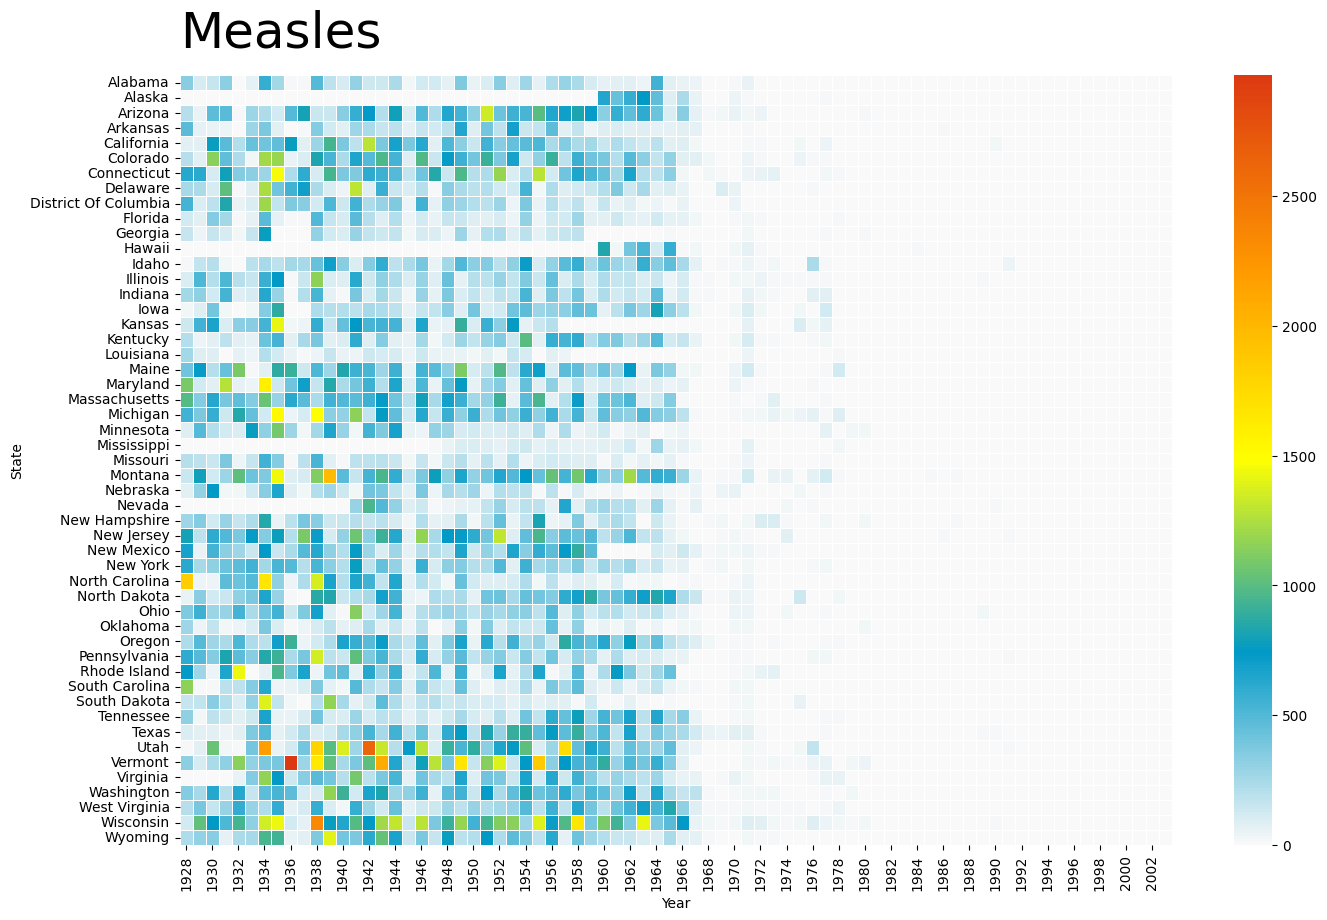

In [27]:
# Pivot the data to have states as rows, years as columns
pivot = data_measles.pivot(index='state', columns='year', values='incidence')

from matplotlib.colors import LinearSegmentedColormap

# Define custom colormap based on the provided colorbar (blue, yellow, orange, red)
custom_cmap = LinearSegmentedColormap.from_list('custom', ["#f9f9f9",'#0099c6', '#ffff00', '#ff9900', '#dc3912'])

plt.figure(figsize=(16, 10))
sns.heatmap(pivot, cmap=custom_cmap, linewidths=0.5, linecolor='white')
plt.title('Measles', fontsize=36, loc='left',pad=20)
plt.xlabel('Year')
plt.ylabel('State')
plt.show()